In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pytest

from QAssemble.Crystal import Crystal
from QAssemble.FLatDyn import FLatDyn, G0
from QAssemble.FLocDyn import FLocDyn
from QAssemble.utility.Causal import CausalFermion
from QAssemble.utility.DLR import DLR


In [ ]:
def _single_band_hubbard():
    crystal = Crystal(
        {
            "RVec": [[1, 0, 0], [0, 1, 0], [0, 0, 1]],
            "Basis": [[[0, 0, 0], 1]],
            "NSpin": 1,
            "NElec": 1.0,
            "KGrid": [2, 2, 2],
        }
    )
    kx, ky, kz = crystal.kpoint[:, 0], crystal.kpoint[:, 1], crystal.kpoint[:, 2]
    eps = -2.0 * (
        np.cos(2.0 * np.pi * kx)
        + np.cos(2.0 * np.pi * ky)
        + np.cos(2.0 * np.pi * kz)
    )
    hamtb = np.zeros((1, 1, 1, crystal.nk), dtype=np.complex128, order="F")
    hamtb[0, 0, 0, :] = eps
    dlr = DLR({"beta": 20.0, "cutoff": 50.0, "eps": 1.0e-12})
    return crystal, dlr, hamtb

In [ ]:
class _Verifier:
    """Independent kernel/moment construction (eval_dlr_freq unit vectors)."""

    def __init__(self, dlr):
        self.beta = float(dlr.beta)
        x = np.asarray(dlr.dF.get_dlr_frequencies(), dtype=float)
        self.nodes = x / self.beta
        self.omega = np.asarray(dlr.omega, dtype=float)
        z = 1j * self.omega
        kernel = np.empty((self.omega.size, x.size), dtype=np.complex128)
        for j in range(x.size):
            unit = np.zeros((x.size, 1, 1), dtype=np.complex128)
            unit[j, 0, 0] = 1.0
            kernel[:, j] = dlr.dF.eval_dlr_freq(unit, z, self.beta, xi=-1)[:, 0, 0]
        self.kernel = kernel
        self.moment_rows = np.vstack([self.nodes**power for power in range(3)])

    def fit(self, values):
        lhs = np.vstack((self.kernel.real, self.kernel.imag))
        rhs = np.concatenate((np.real(values), np.imag(values)))
        coeff, *_ = np.linalg.lstsq(lhs, rhs, rcond=None)
        return np.asarray(coeff, dtype=float)

    def reconstruct(self, coefficients):
        return self.kernel @ np.asarray(coefficients, dtype=float)


def _fermion(dlr, *, constraint_tol=1.0e-7, **kwargs):
    return CausalFermion(
        d=dlr.dF,
        beta=dlr.beta,
        omega=dlr.omega,
        constraint_tol=constraint_tol,
        **kwargs,
    )


def _contaminate(verifier, base, column=0, alpha_extra=0.2):
    """Add a moment-neutral pole-weight perturbation that breaks causality."""
    moment_rows = verifier.moment_rows
    _, _, vh = np.linalg.svd(moment_rows)
    null_space = vh[moment_rows.shape[0]:].T
    direction = null_space[:, column % null_space.shape[1]]
    # flip the coefficient that is smallest in magnitude among the
    # well-supported components, so the contamination stays moderate even
    # when the ill-conditioned fit has produced some huge coefficients
    support = np.where(np.abs(direction) >= 0.3 * np.max(np.abs(direction)))[0]
    idx = int(support[np.argmin(np.abs(base[support]))])
    if direction[idx] < 0.0:
        direction = -direction
    alpha = abs(base[idx]) / direction[idx] + alpha_extra
    bad = base + alpha * direction
    assert np.max(bad) > 0.0
    np.testing.assert_allclose(moment_rows @ bad, moment_rows @ base, atol=1.0e-8)
    return bad


def _causal_coefficients(verifier):
    return -0.2 * np.exp(-0.1 * verifier.nodes**2) - 0.05


def _hubbard_lattice_target(crystal, dlr, hamtb):
    g0 = G0(crystal=crystal, dlr=dlr, hamtb=hamtb, hdf5file=None)
    return np.asfortranarray(g0.kf)


def _assert_projected_channel(verifier, values, moment_target):
    coeff = verifier.fit(values)
    assert np.max(coeff) <= 1.0e-5
    np.testing.assert_allclose(
        verifier.moment_rows @ coeff,
        moment_target,
        atol=1.0e-6,
        rtol=1.0e-6,
    )


def _show_projection_comparison(
    dlr,
    verifier,
    without_noise_values,
    noise_values,
    projected_values,
    without_noise_coefficients,
    noise_coefficients,
    projected_coefficients,
    title,
):
    order = np.argsort(verifier.nodes)
    omega = np.asarray(dlr.omega, dtype=float)
    without_noise_values = np.asarray(without_noise_values, dtype=np.complex128)
    noise_values = np.asarray(noise_values, dtype=np.complex128)
    projected_values = np.asarray(projected_values, dtype=np.complex128)
    series = (
        ("without noise", without_noise_values, without_noise_coefficients, "o-"),
        # ("noise", noise_values, noise_coefficients, "s-"),
        ("causal projection", projected_values, projected_coefficients, "x-"),
    )

    fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.4), constrained_layout=True)
    for label, _, coefficients, marker in series:
        axes[0].plot(
            verifier.nodes[order],
            np.asarray(coefficients)[order],
            marker,
            ms=3,
            lw=1.0,
            label=label,
        )
    axes[0].axhline(0.0, color="black", lw=0.8, ls=":")
    axes[0].set_xlabel(r"$\epsilon_l$")
    axes[0].set_ylabel(r"$A_l$")
    axes[0].set_title("pole weights")
    axes[0].legend(frameon=False, fontsize=8)

    for label, values, _, marker in series:
        axes[1].plot(omega, values.real, marker, lw=1.0, label=label)
    axes[1].set_xlabel(r"$\omega_n$")
    axes[1].set_ylabel(r"$\mathrm{Re}\,G(i\omega_n)$")
    axes[1].set_title("real part")
    axes[1].legend(frameon=False, fontsize=8)

    for label, values, _, marker in series:
        axes[2].plot(omega, values.imag, marker, lw=1.0, label=label)
    axes[2].set_xlabel(r"$\omega_n$")
    axes[2].set_ylabel(r"$\mathrm{Im}\,G(i\omega_n)$")
    axes[2].set_title("imaginary part")
    axes[2].legend(frameon=False, fontsize=8)

    fig.suptitle(title)
    plt.show()
    plt.close(fig)


def _relative_error(candidate, reference, mask=None):
    candidate = np.asarray(candidate, dtype=np.complex128)
    reference = np.asarray(reference, dtype=np.complex128)
    if mask is not None:
        candidate = candidate[mask]
        reference = reference[mask]
    return np.linalg.norm(candidate - reference) / max(np.linalg.norm(reference), 1.0e-30)


def test_flatdyn_causal_projection_single_band_hubbard_grid():
    crystal, dlr, hamtb = _single_band_hubbard()
    assert hamtb.shape == (1, 1, 1, crystal.nk)
    flat = FLatDyn(crystal, dlr)
    verifier = _Verifier(dlr)

    # synthetic non-causal targets built inside the DLR pole basis
    base = _causal_coefficients(verifier)
    nfreq = len(dlr.omega)
    mat = np.zeros((1, 1, 1, crystal.nk, nfreq), dtype=np.complex128, order="F")
    coeffs = []
    for ik in range(crystal.nk):
        bad = _contaminate(verifier, base, column=ik, alpha_extra=0.2 + 0.01 * ik)
        coeffs.append(bad)
        mat[0, 0, 0, ik, :] = verifier.reconstruct(bad)
    original = mat.copy()

    projected = flat.CausalProjection(mat, constraint_tol=1.0e-7)

    assert projected.shape == mat.shape
    assert projected.dtype == np.complex128
    assert projected.flags.f_contiguous
    np.testing.assert_allclose(mat, original)
    for ik in range(crystal.nk):
        _assert_projected_channel(
            verifier,
            projected[0, 0, 0, ik, :],
            verifier.moment_rows @ coeffs[ik],
        )

    ik_plot = 0
    _show_projection_comparison(
        dlr,
        verifier,
        original[0, 0, 0, ik_plot, :],
        original[0, 0, 0, ik_plot, :],
        projected[0, 0, 0, ik_plot, :],
        coeffs[ik_plot],
        coeffs[ik_plot],
        verifier.fit(projected[0, 0, 0, ik_plot, :]),
        "FLatDyn single-band Hubbard k=0",
    )

    # diagnostic on the raw G0: a sharp pole between DLR nodes is
    # interpolated with oscillating mixed-sign weights, so the sufficient
    # pole-weight condition reports it as non-causal — CausalityCheck
    # reports this instead of raising
    g0 = _hubbard_lattice_target(crystal, dlr, hamtb)
    report = flat.CausalityCheck(g0)
    print("CausalityCheck on raw G0 (sharp poles between DLR nodes):")
    print(f"  causal channels: {int(report['causal'].sum())}/{report['causal'].size}")
    print(f"  max inequality violation: {report['max_inequality_violation'].max():.3e}")
    print(f"  max node residual: {report['node_residual'].max():.3e}")


def test_flocdyn_causal_projection_single_band_hubbard_average():
    crystal, dlr, _ = _single_band_hubbard()
    local = FLocDyn(crystal, dlr, projector=None)
    verifier = _Verifier(dlr)
    nfreq = len(dlr.omega)

    clean_coefficients = _causal_coefficients(verifier)
    clean_values = verifier.reconstruct(clean_coefficients)
    clean_moment_target = verifier.moment_rows @ clean_coefficients

    # representable, moment-neutral pole-weight contamination
    noisy_coefficients = _contaminate(verifier, clean_coefficients)
    noisy_local4 = np.zeros((1, 1, 1, nfreq), dtype=np.complex128, order="F")
    noisy_local4[0, 0, 0, :] = verifier.reconstruct(noisy_coefficients)
    local3 = np.asfortranarray(noisy_local4[:, :, 0, :])

    report = local.CausalityCheck(noisy_local4)
    print("CausalityCheck on contaminated input:")
    print(f"  causal: {report['causal'][0, 0]}")
    print(f"  max inequality violation: {report['max_inequality_violation'][0, 0]:.6e}")
    print(f"  node residual: {report['node_residual'][0, 0]:.6e}")

    # moments are anchored internally to the fit of the input (no moments kwarg)
    projected4 = local.CausalProjection(noisy_local4, constraint_tol=1.0e-7)
    projected3 = local.CausalProjection(local3, constraint_tol=1.0e-7)

    assert projected4.shape == noisy_local4.shape
    assert projected3.shape == local3.shape
    assert projected4.flags.f_contiguous
    assert projected3.flags.f_contiguous
    np.testing.assert_allclose(projected4[:, :, 0, :], projected3)

    _assert_projected_channel(verifier, projected4[0, 0, 0, :], clean_moment_target)

    noise_values = noisy_local4[0, 0, 0, :]
    projected_values = projected4[0, 0, 0, :]
    recovery = {
        "noise_all": _relative_error(noise_values, clean_values),
        "projected_all": _relative_error(projected_values, clean_values),
    }
    print("Recovery relative errors against the clean causal target:")
    for key, value in recovery.items():
        print(f"  {key:>14s}: {value:.6e}")
    print(
        "  improvement factor: "
        f"{recovery['noise_all'] / max(recovery['projected_all'], 1.0e-30):.6e}"
    )

    # the node-fit gate rejects data that left the causal pole basis
    rng = np.random.default_rng(20260612)
    nonhermitian = noisy_local4.copy(order="F")
    nonhermitian[0, 0, 0, :] += 1.0e-3 * (
        rng.normal(size=nfreq) + 1j * rng.normal(size=nfreq)
    )
    try:
        local.CausalProjection(nonhermitian)
    except RuntimeError as exc:
        print(f"gate rejected non-Hermitian noise:\n  {exc}")

    _show_projection_comparison(
        dlr,
        verifier,
        clean_values,
        noise_values,
        projected_values,
        clean_coefficients,
        verifier.fit(noise_values),
        verifier.fit(projected_values),
        "FLocDyn single-band Hubbard local channel (pole-weight contamination)",
    )


Recovery relative errors against noise-free G0 local:
       noise_all: 3.660258e+00
   projected_all: 1.515566e-02
      noise_high: 4.358187e+01
  projected_high: 2.366574e-03
       noise_low: 0.000000e+00
   projected_low: 1.520809e-02
  all-frequency improvement factor: 2.415109e+02
  high-frequency improvement factor: 1.841559e+04


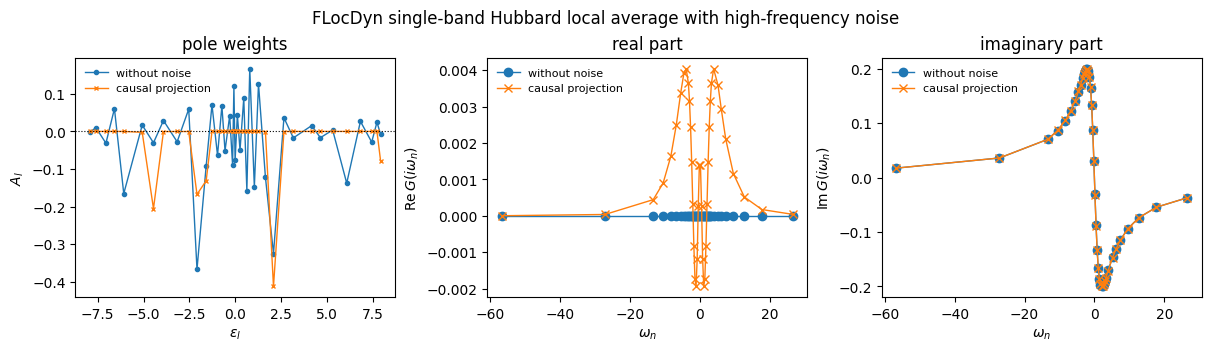

In [4]:
test_flocdyn_causal_projection_single_band_hubbard_average()

In [6]:
crystal, dlr, hamtb = _single_band_hubbard()
mat = _hubbard_lattice_target(crystal, dlr, hamtb)
local4 = np.asfortranarray(np.mean(mat, axis=3))

In [8]:
mat[0, 0, 0, 0, :]

array([0.00184528+0.01743965j, 0.00774725+0.03508829j,
       0.02800209+0.0623129j , 0.04088262+0.0717104j ,
       0.05697503+0.07905494j, 0.07350937+0.08275225j,
       0.09059932+0.08301596j, 0.1057253 +0.08026858j,
       0.11668326+0.07636902j, 0.12798297+0.07036231j,
       0.13360851+0.06645939j, 0.13911176+0.06191294j,
       0.14439859+0.05670519j, 0.14936554+0.05083495j,
       0.15390316+0.04432093j, 0.15790058+0.03720445j,
       0.1612512 +0.02955082j, 0.16385899+0.02144909j,
       0.16564489+0.01300972j, 0.16655251+0.00436033j,
       0.16655251-0.00436033j, 0.16564489-0.01300972j,
       0.16385899-0.02144909j, 0.1612512 -0.02955082j,
       0.15790058-0.03720445j, 0.15390316-0.04432093j,
       0.14936554-0.05083495j, 0.14439859-0.05670519j,
       0.13911176-0.06191294j, 0.13360851-0.06645939j,
       0.12798297-0.07036231j, 0.11668326-0.07636902j,
       0.09543503-0.08244995j, 0.08160027-0.08331531j,
       0.06629476-0.08157286j, 0.04694395-0.07496838j,
       0.0

In [9]:
mat_T = np.transpose(mat[:, :, 0, 0, :])

In [ ]:
mat_T2 = mat_T.reshape((-1, 1))

In [15]:
mat_dlr_coefficients = dlr.dF.dlr_from_matsubara(mat_T2, beta=dlr.beta, xi=-1)

In [16]:
mat_dlr_coefficients.shape

(39, 1)

In [ ]:
mat_dlr_coefficients = mat_dlr_coefficients.reshape((len(dlr.omega), 1,1))

In [19]:
print(mat_dlr_coefficients.shape)

(39, 1, 1)


In [20]:
mat_reconstruct = dlr.dF.matsubara_from_dlr(mat_dlr_coefficients.reshape((len(dlr.omega),1)), beta=dlr.beta, xi=-1)

In [22]:
np.allclose(mat_reconstruct, mat_T2)

True

In [30]:
mat_dlr_coefficients2 = dlr.dF.lstsq_dlr_from_matsubara(dlr.omega, mat_T, beta=dlr.beta)

In [31]:
print(mat_dlr_coefficients.shape)
np.allclose(mat_dlr_coefficients, mat_dlr_coefficients2)

(39, 1, 1)


False

In [34]:
np.sum(mat_dlr_coefficients, axis=0)

array([[-1.-4.29907993e-11j]])

In [29]:
mat_dlr_coefficients

array([[[-0.0055826 -0.0003314j ]],

       [[ 0.02396096+0.00122306j]],

       [[-0.08965469-0.00320495j]],

       [[ 0.22416912+0.00472876j]],

       [[-1.11701183-0.00338724j]],

       [[-0.06051573+0.00244766j]],

       [[ 0.03874455-0.00283291j]],

       [[-0.01829042+0.00195553j]],

       [[ 0.00660472-0.0010693j ]],

       [[-0.00461172+0.00100445j]],

       [[ 0.00360796-0.00095108j]],

       [[-0.00339911+0.00109062j]],

       [[ 0.00393827-0.00141973j]],

       [[-0.00427739+0.00171519j]],

       [[ 0.0049602 -0.0021564j ]],

       [[-0.00388743+0.00178726j]],

       [[ 0.00319699-0.00159382j]],

       [[-0.00678157+0.00354965j]],

       [[ 0.00907104-0.0048535j ]],

       [[-0.00582517+0.00317794j]],

       [[ 0.00325852-0.00184394j]],

       [[-0.00353803+0.00208736j]],

       [[ 0.00586715-0.00366566j]],

       [[-0.00985083+0.00644363j]],

       [[ 0.00956008-0.00651963j]],

       [[-0.00713534+0.00518619j]],

       [[ 0.00489571-0.00375876j]],

 